In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator
from sklearn.model_selection import train_test_split #skykitlearn for machine learning
from sklearn.linear_model import PassiveAggressiveRegressor #leaner model 
df_patients = pd.read_csv('patients.csv')
df_outcomes = pd.read_csv('outcomes.csv')


In [3]:
# 1 Merge the data directly on patient_id to combine clinical vitals and charges
df = pd.merge(df_patients, df_outcomes, on='patient_id', how='inner')
    
print(f" Data loaded and merged! Combined Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2 Export the merged dataframe to Excel(Here Merged DATA & Exported into Excel)
df.to_excel('clinical_financial_audit.xlsx', sheet_name='Master_Data', index=False)
print("💾 Master data exported  to clinical_financial_audit.xlsx")


 Data loaded and merged! Combined Rows: 11001, Columns: 39
💾 Master data exported  to clinical_financial_audit.xlsx


In [13]:
# 2. Filtering Correlated Matrix

continuous_vars = ['bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'total_charges_usd']

df_filtered = df[continuous_vars]

correlation_matrix = df_filtered.corr()
print("\n Bars Correlation Matrix Numerical Summary:")
print(correlation_matrix)




 Bars Correlation Matrix Numerical Summary:
                        bmi  systolic_bp  diastolic_bp  heart_rate  \
bmi                1.000000    -0.005762     -0.012919    0.005178   
systolic_bp       -0.005762     1.000000      0.083075    0.015242   
diastolic_bp      -0.012919     0.083075      1.000000   -0.001871   
heart_rate         0.005178     0.015242     -0.001871    1.000000   
total_charges_usd -0.008432     0.004763      0.018110   -0.008010   

                   total_charges_usd  
bmi                        -0.008432  
systolic_bp                 0.004763  
diastolic_bp                0.018110  
heart_rate                 -0.008010  
total_charges_usd           1.000000  


💾 Heatmap saved as 'clinical_financial_correlation_heatmap.png'


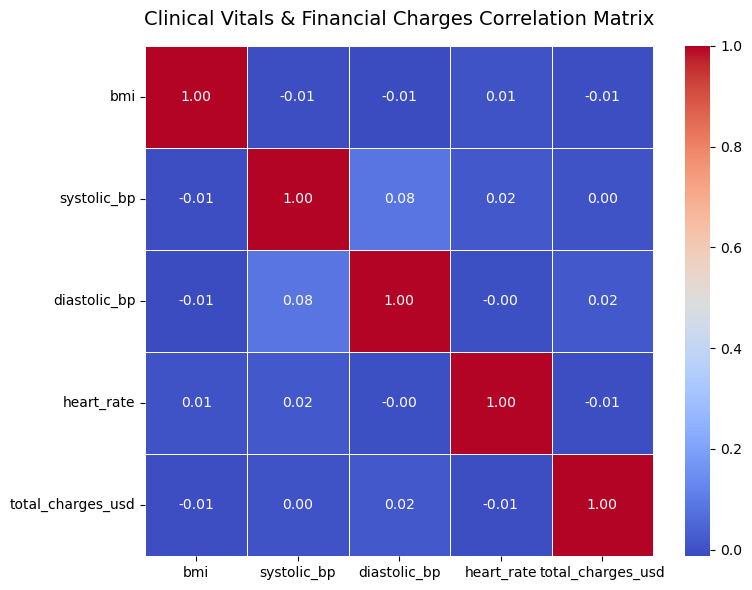

In [14]:
# 3.Correlation Between Cinical VItals & Finanacial Charges 

plt.figure(figsize=(8, 6))

# Generate the heatmap
# 'annot=True' prints the exact correlation numbers inside the squares
# 'cmap='coolwarm'' colors negative correlations blue and positive correlations red
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Clinical Vitals & Financial Charges Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()

# Save the plot locally
plt.savefig('clinical_financial_correlation_heatmap.png', dpi=300)
print("💾 Heatmap saved as 'clinical_financial_correlation_heatmap.png'")
plt.show()



💾 Distribution plots saved as 'operational_distributions.png'


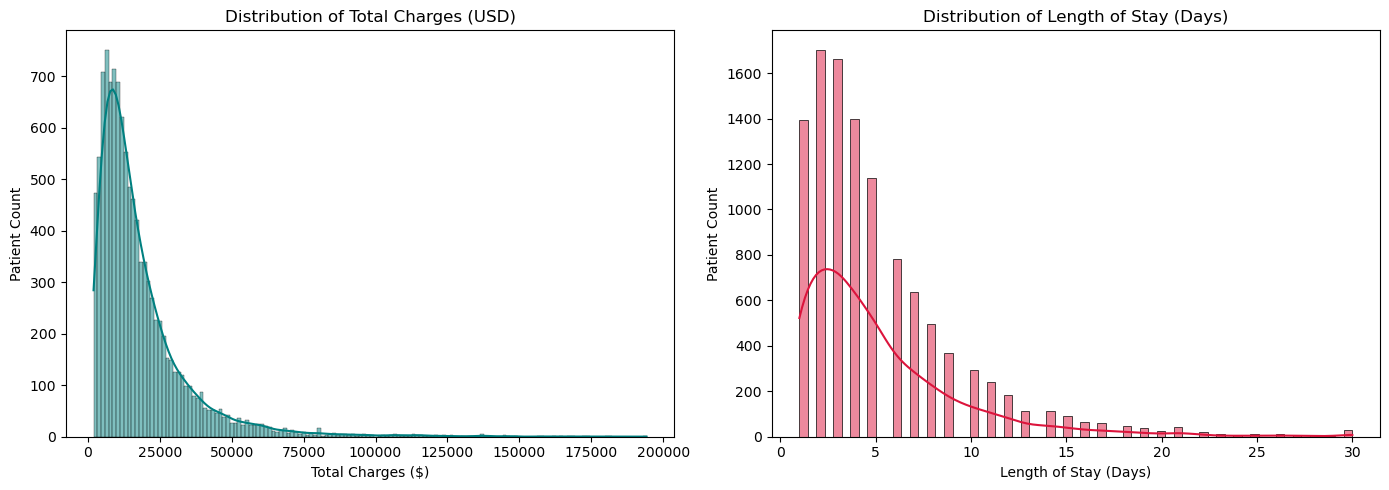

In [15]:
# $ Distribution of Total Charges & Length of stays
# Set up a side-by-side plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Charges Distribution
sns.histplot(data=df, x='total_charges_usd', kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Total Charges (USD)', fontsize=12)
axes[0].set_xlabel('Total Charges ($)')
axes[0].set_ylabel('Patient Count')

# Plot 2: Length of Stay Distribution
sns.histplot(data=df, x='length_of_stay_days', kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Distribution of Length of Stay (Days)', fontsize=12)
axes[1].set_xlabel('Length of Stay (Days)')
axes[1].set_ylabel('Patient Count')

plt.tight_layout()

# Save the distributions plot locally
plt.savefig('operational_distributions.png', dpi=300)
print("💾 Distribution plots saved as 'operational_distributions.png'")
plt.show()
